# FireSpec — Notebook 04: Multi-Temporal Recovery Trajectories

This is the fourth notebook of the FireSpec submission to the
[Planet Tanager Open Data Competition](https://www.planet.com/tanager-open-data-competition/).
Notebook 02 answered *how severely did it burn* with a single pre/post dNBR snapshot; Notebook
03 answered *how dry is the standing fuel right now*. This notebook asks the question neither of
those can: **how is the landscape changing over time?** A single dNBR value is a photograph of
one moment in a multi-year ecological process — it cannot distinguish a site that recovers in
18 months from one that takes 8 years, and it says nothing about whether high-severity patches
are actually regenerating slower than low-severity ones (they usually are — that differential
*is* the actionable signal for land managers).

## Why a trajectory, not a snapshot

Fernandez-Manso et al. (2016, *Remote Sensing of Environment* 184) tracked MESMA fraction
abundances (char/ash, non-photosynthetic vegetation, photosynthetic vegetation) through a
15-year Landsat time series after a large Spanish wildfire and reconstructed the canonical
post-fire recovery arc: **char/ash dominance → NPV accumulation → PV re-establishment**, with
the *rate* of that transition strongly correlated to initial burn severity — higher-severity
sites recover measurably slower. That is exactly the kind of finding a single before/after pair
cannot produce, and — per that same review — **no published spaceborne hyperspectral
multi-temporal fire study has attempted it.** Tanager-1's repeat coverage over the January 2025
LA-area fire complex is FireSpec's shot at being first.

## The Tanager time series behind this claim

`tanager.config.FIRE_SCENES` — the project's hardcoded scene catalog — lists **7 distinct
acquisition dates** spanning December 2024 through September 2025 relevant to this competition
(a handful of the raw catalog entries are duplicate along-track swaths from the same overpass,
and two dates are an unrelated Utah calibration site, filtered out below):


In [1]:
import logging
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import tanager
from tanager.config import SENSOR, FIRE_SCENES, DATA_DIR
from tanager.io import reproject_to_common_grid
from tanager.masks import nodata_mask, cloud_mask, water_mask, apply_masks
from tanager.spectral import nbr, ndvi, dnbr
from tanager.lfmc import compute_lfmc_indices

logging.basicConfig(level=logging.WARNING)
%matplotlib inline

print(f"tanager package version: {tanager.__version__}")
print(f"Sensor: {SENSOR.name} — {SENSOR.n_bands} bands, {SENSOR.wavelength_min_nm}-{SENSOR.wavelength_max_nm} nm")
print(f"Local data directory: {DATA_DIR}")

tanager package version: 0.1.0
Sensor: Tanager-1 — 426 bands, 380-2500 nm
Local data directory: /home/gprice/projects/tanager/data/raw/fire


In [2]:
catalog_df = pd.DataFrame.from_dict(FIRE_SCENES, orient="index")
catalog_df.index.name = "scene_id"
catalog_df["date"] = pd.to_datetime(catalog_df["datetime"]).dt.date
catalog_df["local_file"] = [
    "yes" if (DATA_DIR / f"{sid}_ortho_sr_hdf5.h5").exists() else "no"
    for sid in catalog_df.index
]

unique_dates = sorted(catalog_df["date"].unique())
print(f"FIRE_SCENES catalog: {len(catalog_df)} scenes across {len(unique_dates)} unique acquisition dates")
print(f"Dates: {[d.isoformat() for d in unique_dates]}")

la_area = catalog_df[catalog_df["phase"] != "other"]
print(f"\nLA-area (fire-relevant) scenes: {len(la_area)} across {la_area['date'].nunique()} unique dates")
print(f"Locally downloaded: {(catalog_df['local_file'] == 'yes').sum()} of {len(catalog_df)} cataloged scenes")

catalog_df[["date", "phase", "days_relative_to_ignition", "notes", "local_file"]]

FIRE_SCENES catalog: 11 scenes across 7 unique acquisition dates
Dates: ['2024-12-15', '2025-01-23', '2025-04-07', '2025-07-24', '2025-07-26', '2025-09-02', '2025-09-20']

LA-area (fire-relevant) scenes: 8 across 5 unique dates
Locally downloaded: 4 of 11 cataloged scenes


,date,phase,days_relative_to_ignition,notes,local_file
scene_id,,,,,
20241215_185916_33_4001,2024-12-15,pre-fire,-23.0,Pre-fire baseline; ~23 days before Palisades/E...,yes
20250123_185507_64_4001,2025-01-23,post-fire,16.0,Immediate post-fire; primary swath over burn scar,yes
20250123_185518_92_4001,2025-01-23,post-fire,16.0,Immediate post-fire; adjacent swath,yes
20250407_192235_24_4001,2025-04-07,early-recovery,90.0,Early recovery (~90 days post-ignition); prima...,yes
20250407_192229_16_4001,2025-04-07,early-recovery,90.0,Early recovery (~90 days post-ignition); adjac...,no
20250724_190927_83_4001,2025-07-24,other,NaN,"Utah (38.5°N, -112°W); outside LA fire footprint",no
20250726_192343_21_4001,2025-07-26,mid-recovery,200.0,Mid-recovery (~200 days post-ignition),no
20250726_192422_87_4001,2025-07-26,mid-recovery,200.0,Mid-recovery (~200 days post-ignition); adjace...,no
20250902_190116_02_4001,2025-09-02,other,NaN,"Utah (38.5°N, -112°W); outside LA fire footprint",no


**Reading this table honestly.** The catalog's 7 dates are real Tanager-1 acquisitions over
this region, but "7 dates in the catalog" is not the same claim as "7-point trajectory over one
fire footprint" — Section 2 below verifies exactly which scenes share enough geographic overlap
to be combined, rather than assuming the catalog's date span implies a clean single-footprint
time series. Only **4 of the 11 cataloged scenes** (representing 3 of the 7 dates — Dec 15,
Jan 23, and Apr 7) are downloaded locally in `data/raw/fire/`; the Jul 26 and Sep 20 dates exist
in the catalog but have not been pulled down for this notebook. That gap, and what it means for
the trajectory below, is addressed directly rather than glossed over.

## 2. Multi-Date Loading

**Gotcha — TD-7 (pre-fire scene ~60 km from the post-fire swath).** Project notes flag the
December 15 pre-fire scene as roughly 60 km from "the" post-fire footprint. As Notebooks 01/02
established, that risk is specific to the *first* Jan 23 swath (`20250123_185507`, which covers
the Hughes fire near Lake Hughes, ~34.5°N) — the *second* Jan 23 swath
(`20250123_185518`, 11 seconds later along-track) drops south into the Palisades/Topanga
footprint and overlaps the Dec 15 scene by 85.6% of its area. That finding is re-verified from
scratch below, not assumed, because the same question resurfaces for the April 7 scene: does it
extend the *Palisades* trajectory, or does it — like Jan 23 swath 1 — belong to a different
along-track footprint entirely? We answer this with actual bounds intersection, not the
scene's `phase` label in `FIRE_SCENES` (which only encodes days-since-ignition, not location).

We load all four locally available scenes restricted to a 550–2210 nm slice — this single
contiguous range covers every band `nbr()`, `ndvi()`, `water_mask()`, and
`compute_lfmc_indices()` need (Green/Red/NIR/SWIR2 aliases plus the full 860–2130 nm water-index
span), while skipping the ~150 unneeded UV/blue bands and everything past 2210 nm, keeping the
per-scene load fast even though each HDF5 file is ~0.8–1.4 GB on disk.

In [3]:
SCENE_IDS = {
    "dec15": "20241215_185916_33_4001",
    "jan23_swath1": "20250123_185507_64_4001",
    "jan23_swath2": "20250123_185518_92_4001",
    "apr7": "20250407_192235_24_4001",
}
LOAD_RANGE = (550.0, 2210.0)


def local_scene_path(scene_id: str) -> Path:
    return DATA_DIR / f"{scene_id}_ortho_sr_hdf5.h5"


def load_labeled_scene(label: str) -> xr.Dataset:
    scene_id = SCENE_IDS[label]
    path = local_scene_path(scene_id)
    if not path.exists():
        raise FileNotFoundError(
            f"{label} ({scene_id}) not found at {path}. Download it first, e.g.:\n"
            f"  tanager.download_scene(item, 'ortho_sr_hdf5', DATA_DIR)"
        )
    t0 = time.time()
    ds = tanager.load_ortho_scene(path, wavelength_range=LOAD_RANGE)
    print(f"  [{label:12s}] {scene_id}: {dict(ds.sizes)} in {time.time() - t0:.1f}s")
    return ds


print("Loading 4 locally available scenes (550-2210 nm slice)...")
raw_scenes = {label: load_labeled_scene(label) for label in SCENE_IDS}

Loading 4 locally available scenes (550-2210 nm slice)...


  [dec15       ] 20241215_185916_33_4001: {'wavelength': 332, 'y': 713, 'x': 791} in 4.3s


  [jan23_swath1] 20250123_185507_64_4001: {'wavelength': 332, 'y': 1047, 'x': 961} in 6.0s


  [jan23_swath2] 20250123_185518_92_4001: {'wavelength': 332, 'y': 1063, 'x': 957} in 6.1s


  [apr7        ] 20250407_192235_24_4001: {'wavelength': 332, 'y': 869, 'x': 1039} in 5.6s


In [4]:
from tanager.io import get_spatial_info


def _pixel_edge_bounds(ds: xr.Dataset) -> tuple:
    info = get_spatial_info(ds)
    xmin, ymin, xmax, ymax = info["bounds"]
    if info["resolution"] is not None:
        dx, dy = info["resolution"]
        xmin, ymin, xmax, ymax = xmin - dx / 2, ymin - dy / 2, xmax + dx / 2, ymax + dy / 2
    return (xmin, ymin, xmax, ymax)


def _bounds_area(b: tuple) -> float:
    return max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])


def _intersect(b1: tuple, b2: tuple):
    x0, y0 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x1, y1 = min(b1[2], b2[2]), min(b1[3], b2[3])
    if x1 <= x0 or y1 <= y0:
        return None
    return (x0, y0, x1, y1)


bounds = {label: _pixel_edge_bounds(ds) for label, ds in raw_scenes.items()}

print("Pairwise overlap matrix (fraction of the SMALLER scene's area covered by the intersection):\n")
labels = list(bounds)
overlap_rows = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        a, b = labels[i], labels[j]
        inter = _intersect(bounds[a], bounds[b])
        if inter is None:
            overlap_rows.append({"pair": f"{a} <-> {b}", "overlap_km2": 0.0, "frac_smaller": 0.0})
            print(f"  {a:14s} <-> {b:14s}: NO OVERLAP")
        else:
            smaller = min(_bounds_area(bounds[a]), _bounds_area(bounds[b]))
            frac = _bounds_area(inter) / smaller if smaller > 0 else 0.0
            overlap_rows.append(
                {"pair": f"{a} <-> {b}", "overlap_km2": _bounds_area(inter) / 1e6, "frac_smaller": frac}
            )
            print(
                f"  {a:14s} <-> {b:14s}: {_bounds_area(inter) / 1e6:7.1f} km^2 overlap "
                f"({frac:.1%} of the smaller scene)"
            )

overlap_df = pd.DataFrame(overlap_rows)

Pairwise overlap matrix (fraction of the SMALLER scene's area covered by the intersection):

  dec15          <-> jan23_swath1  : NO OVERLAP
  dec15          <-> jan23_swath2  :   434.4 km^2 overlap (85.6% of the smaller scene)
  dec15          <-> apr7          : NO OVERLAP
  jan23_swath1   <-> jan23_swath2  : NO OVERLAP
  jan23_swath1   <-> apr7          :   270.6 km^2 overlap (33.3% of the smaller scene)
  jan23_swath2   <-> apr7          : NO OVERLAP


**Verified, not assumed:** the April 7 scene does **not** extend the Palisades (Dec 15 /
Jan 23 swath 2) footprint — it shares zero overlap with either. Instead it lines up with Jan 23
swath 1, the Hughes-fire swath that the Palisades pair explicitly excludes. In other words, the
four locally downloaded scenes split cleanly into **two disjoint, unconnected footprints**:

| Footprint | Scenes | Dates | What it shows |
|---|---|---|---|
| **Palisades / Topanga** | `dec15` → `jan23_swath2` | Dec 15, 2024 → Jan 23, 2025 (pre-fire → +16 d post-fire) | The acute fire-effect drop |
| **Hughes (Lake Hughes)** | `jan23_swath1` → `apr7` | Jan 23, 2025 → Apr 7, 2025 (~day 1 → +74 d post-ignition) | Early post-fire recovery |

This contradicts the assumption that Dec 15 + Jan 23 + Apr 7 forms one continuous
single-footprint trajectory — it does not, with the data currently on disk. It is not a data
bug: it is a real consequence of Tanager-1's ~18 km swath width and near-polar orbit, where two
overpasses eleven seconds apart on the same day already straddle two different fire complexes
~50 km apart, and the *next* overpass (11 weeks later) happened to revisit the northern one, not
the southern one. Rather than force a scientifically invalid post-fire→post-fire "pre/post" pair
(the mistake `outputs/dnbr_overlap_analysis.md` documents and fixes for Notebook 02), we treat
this as two honest, real two-date trajectories below — one capturing the fire event itself, one
capturing early recovery — and are explicit in Section 6 about exactly which additional catalog
scenes would need downloading to merge them into a single 4+ point series.

In [5]:
PALISADES_DATES = ["dec15", "jan23_swath2"]
HUGHES_DATES = ["jan23_swath1", "apr7"]

SCENE_DATETIME = {
    label: pd.to_datetime(FIRE_SCENES[sid]["datetime"]).tz_localize(None)
    for label, sid in SCENE_IDS.items()
}
for label, dt in SCENE_DATETIME.items():
    print(f"  {label:14s} {SCENE_IDS[label]}  acquired {dt}")

FIRE_IGNITION_PALISADES_EATON = "2025-01-07"  # Key & Benson (2006)-style reference date used throughout FireSpec
FIRE_IGNITION_HUGHES = "2025-01-22"  # per public CAL FIRE / NIFC incident reports; Tanager Jan 23 swath 1 is ~day 1 post-ignition

  dec15          20241215_185916_33_4001  acquired 2024-12-15 18:59:16
  jan23_swath1   20250123_185507_64_4001  acquired 2025-01-23 18:55:07
  jan23_swath2   20250123_185518_92_4001  acquired 2025-01-23 18:55:18
  apr7           20250407_192235_24_4001  acquired 2025-04-07 19:22:35


**Quality masking and spatial alignment.** As in Notebooks 02–03, we stack the standard
nodata + cloud/cirrus + water mask before any index math, then call
`tanager.io.reproject_to_common_grid()` **within each footprint pair separately** — the two
footprints don't overlap each other, so aligning all four scenes to one grid at once would just
raise `ValueError` (ask it to intersect two rectangles that don't touch). Each pair gets its own
30 m common UTM grid restricted to the pair's actual intersection.

In [6]:
def mask_scene(ds: xr.Dataset, path: Path, label: str) -> xr.Dataset:
    '''Apply the standard nodata + cloud + water mask stack to a scene.'''
    masks = [nodata_mask(ds)]
    try:
        masks.append(cloud_mask(ds, filepath=path))
    except Exception as exc:
        print(f"  [{label}] cloud_mask not applied: {exc}")
    try:
        masks.append(water_mask(ds))
    except Exception as exc:
        print(f"  [{label}] water_mask not applied: {exc}")

    masked = apply_masks(ds, masks)
    data_var = ds.attrs.get("data_var", "surface_reflectance")
    total = int(ds.sizes["y"] * ds.sizes["x"])
    valid = int(np.isfinite(masked[data_var].isel(wavelength=0).values).sum())
    print(f"  [{label:14s}] {len(masks)} masks applied; valid pixels {valid:,}/{total:,} ({100.0 * valid / total:.1f}%)")
    return masked


masked_scenes = {
    label: mask_scene(ds, local_scene_path(SCENE_IDS[label]), label) for label, ds in raw_scenes.items()
}

  [dec15         ] 3 masks applied; valid pixels 173,100/563,983 (30.7%)


  [jan23_swath1  ] 3 masks applied; valid pixels 678,672/1,006,167 (67.5%)


  [jan23_swath2  ] 3 masks applied; valid pixels 377,590/1,017,291 (37.1%)


  [apr7          ] 3 masks applied; valid pixels 683,948/902,891 (75.8%)


In [7]:
t0 = time.time()
pal_aligned = dict(zip(PALISADES_DATES, reproject_to_common_grid([masked_scenes[d] for d in PALISADES_DATES])))
print(f"Palisades pair aligned in {time.time() - t0:.1f}s: {dict(pal_aligned['dec15'].sizes)}")

t0 = time.time()
hug_aligned = dict(zip(HUGHES_DATES, reproject_to_common_grid([masked_scenes[d] for d in HUGHES_DATES])))
print(f"Hughes pair aligned in {time.time() - t0:.1f}s: {dict(hug_aligned['jan23_swath1'].sizes)}")

aligned_scenes = {**pal_aligned, **hug_aligned}

Palisades pair aligned in 7.1s: {'x': 677, 'y': 713, 'wavelength': 332}


Hughes pair aligned in 5.9s: {'x': 346, 'y': 869, 'wavelength': 332}


**Spectral indices per date.** `tanager.nbr()` and `tanager.ndvi()` run directly on each
aligned scene — because every date within a footprint now shares identical `(y, x)` coordinates,
the resulting index maps are pixel-for-pixel comparable across time without any further
resampling.

In [8]:
nbr_by_date = {label: nbr(ds) for label, ds in aligned_scenes.items()}
ndvi_by_date = {label: ndvi(ds) for label, ds in aligned_scenes.items()}

for label in SCENE_IDS:
    nbr_v = np.asarray(nbr_by_date[label].values, dtype=np.float64)
    ndvi_v = np.asarray(ndvi_by_date[label].values, dtype=np.float64)
    print(
        f"  [{label:14s}] NBR  mean={np.nanmean(nbr_v):+.3f} median={np.nanmedian(nbr_v):+.3f}  "
        f"NDVI mean={np.nanmean(ndvi_v):+.3f} median={np.nanmedian(ndvi_v):+.3f}  "
        f"n_finite={int(np.isfinite(nbr_v).sum()):,}"
    )

  [dec15         ] NBR  mean=+0.235 median=+0.272  NDVI mean=+0.498 median=+0.547  n_finite=159,782
  [jan23_swath1  ] NBR  mean=+0.007 median=+0.014  NDVI mean=+0.266 median=+0.251  n_finite=197,640
  [jan23_swath2  ] NBR  mean=+0.086 median=+0.121  NDVI mean=+0.386 median=+0.399  n_finite=162,110
  [apr7          ] NBR  mean=+0.210 median=+0.204  NDVI mean=+0.535 median=+0.569  n_finite=203,213


**LFMC proxy per date.** Full PLSR-calibrated LFMC (Notebook 03's Tier 2) requires a
trained model artifact that is not checked into this repo. For a 4-scene trajectory we reuse
Notebook 03's Tier-1 water index stack instead — `tanager.compute_lfmc_indices()` — and carry
forward **SAI970** (Spectral Absorption Index at the 970 nm liquid-water feature; Quan et al.
2021) as the trajectory's "LFMC proxy" panel: higher SAI970 = deeper water absorption = wetter
fuel, no training data required, interpretable, and directly comparable in orientation to NBR
and NDVI (higher = healthier/wetter in all three).

In [9]:
t0 = time.time()
lfmc_indices_by_date = {label: compute_lfmc_indices(ds) for label, ds in aligned_scenes.items()}
print(f"compute_lfmc_indices on all 4 aligned scenes: {time.time() - t0:.1f}s")

sai970_by_date = {label: lfmc_indices_by_date[label]["SAI970"] for label in SCENE_IDS}
for label in SCENE_IDS:
    v = np.asarray(sai970_by_date[label].values, dtype=np.float64)
    print(f"  [{label:14s}] SAI970 mean={np.nanmean(v):+.4f}  n_finite={int(np.isfinite(v).sum()):,}")

compute_lfmc_indices on all 4 aligned scenes: 59.4s
  [dec15         ] SAI970 mean=+0.0526  n_finite=159,782
  [jan23_swath1  ] SAI970 mean=+0.0190  n_finite=197,640
  [jan23_swath2  ] SAI970 mean=+0.0333  n_finite=162,110
  [apr7          ] SAI970 mean=+0.0646  n_finite=203,213


## 3. Temporal Trajectories

`tanager.plot_temporal_trajectory()` renders a scene-wide mean ± 1 std trajectory with the fire
ignition date marked as a red dashed line and shaded pre-fire/post-fire backgrounds. We plot
NBR, NDVI, and the SAI970 LFMC proxy for both footprints side by side: the **left** column is
the Palisades fire-effect trajectory (2 dates spanning ignition), the **right** column is the
Hughes early-recovery trajectory (2 dates, both post-ignition).

**Known limitation — TANAGER-37 (north-south orientation).** As documented in Notebooks 02–03,
`plot_map()` (used later in this section and in Section 4) always calls `imshow(...,
origin="lower")` rather than inferring orientation from Tanager's descending-`y` coordinate
convention; on these scenes that produces a vertically mirrored raster inside a correctly
UTM-labeled extent. `plot_temporal_trajectory()` is unaffected (it has no spatial axis), but the
map panels below should be read with that caveat.

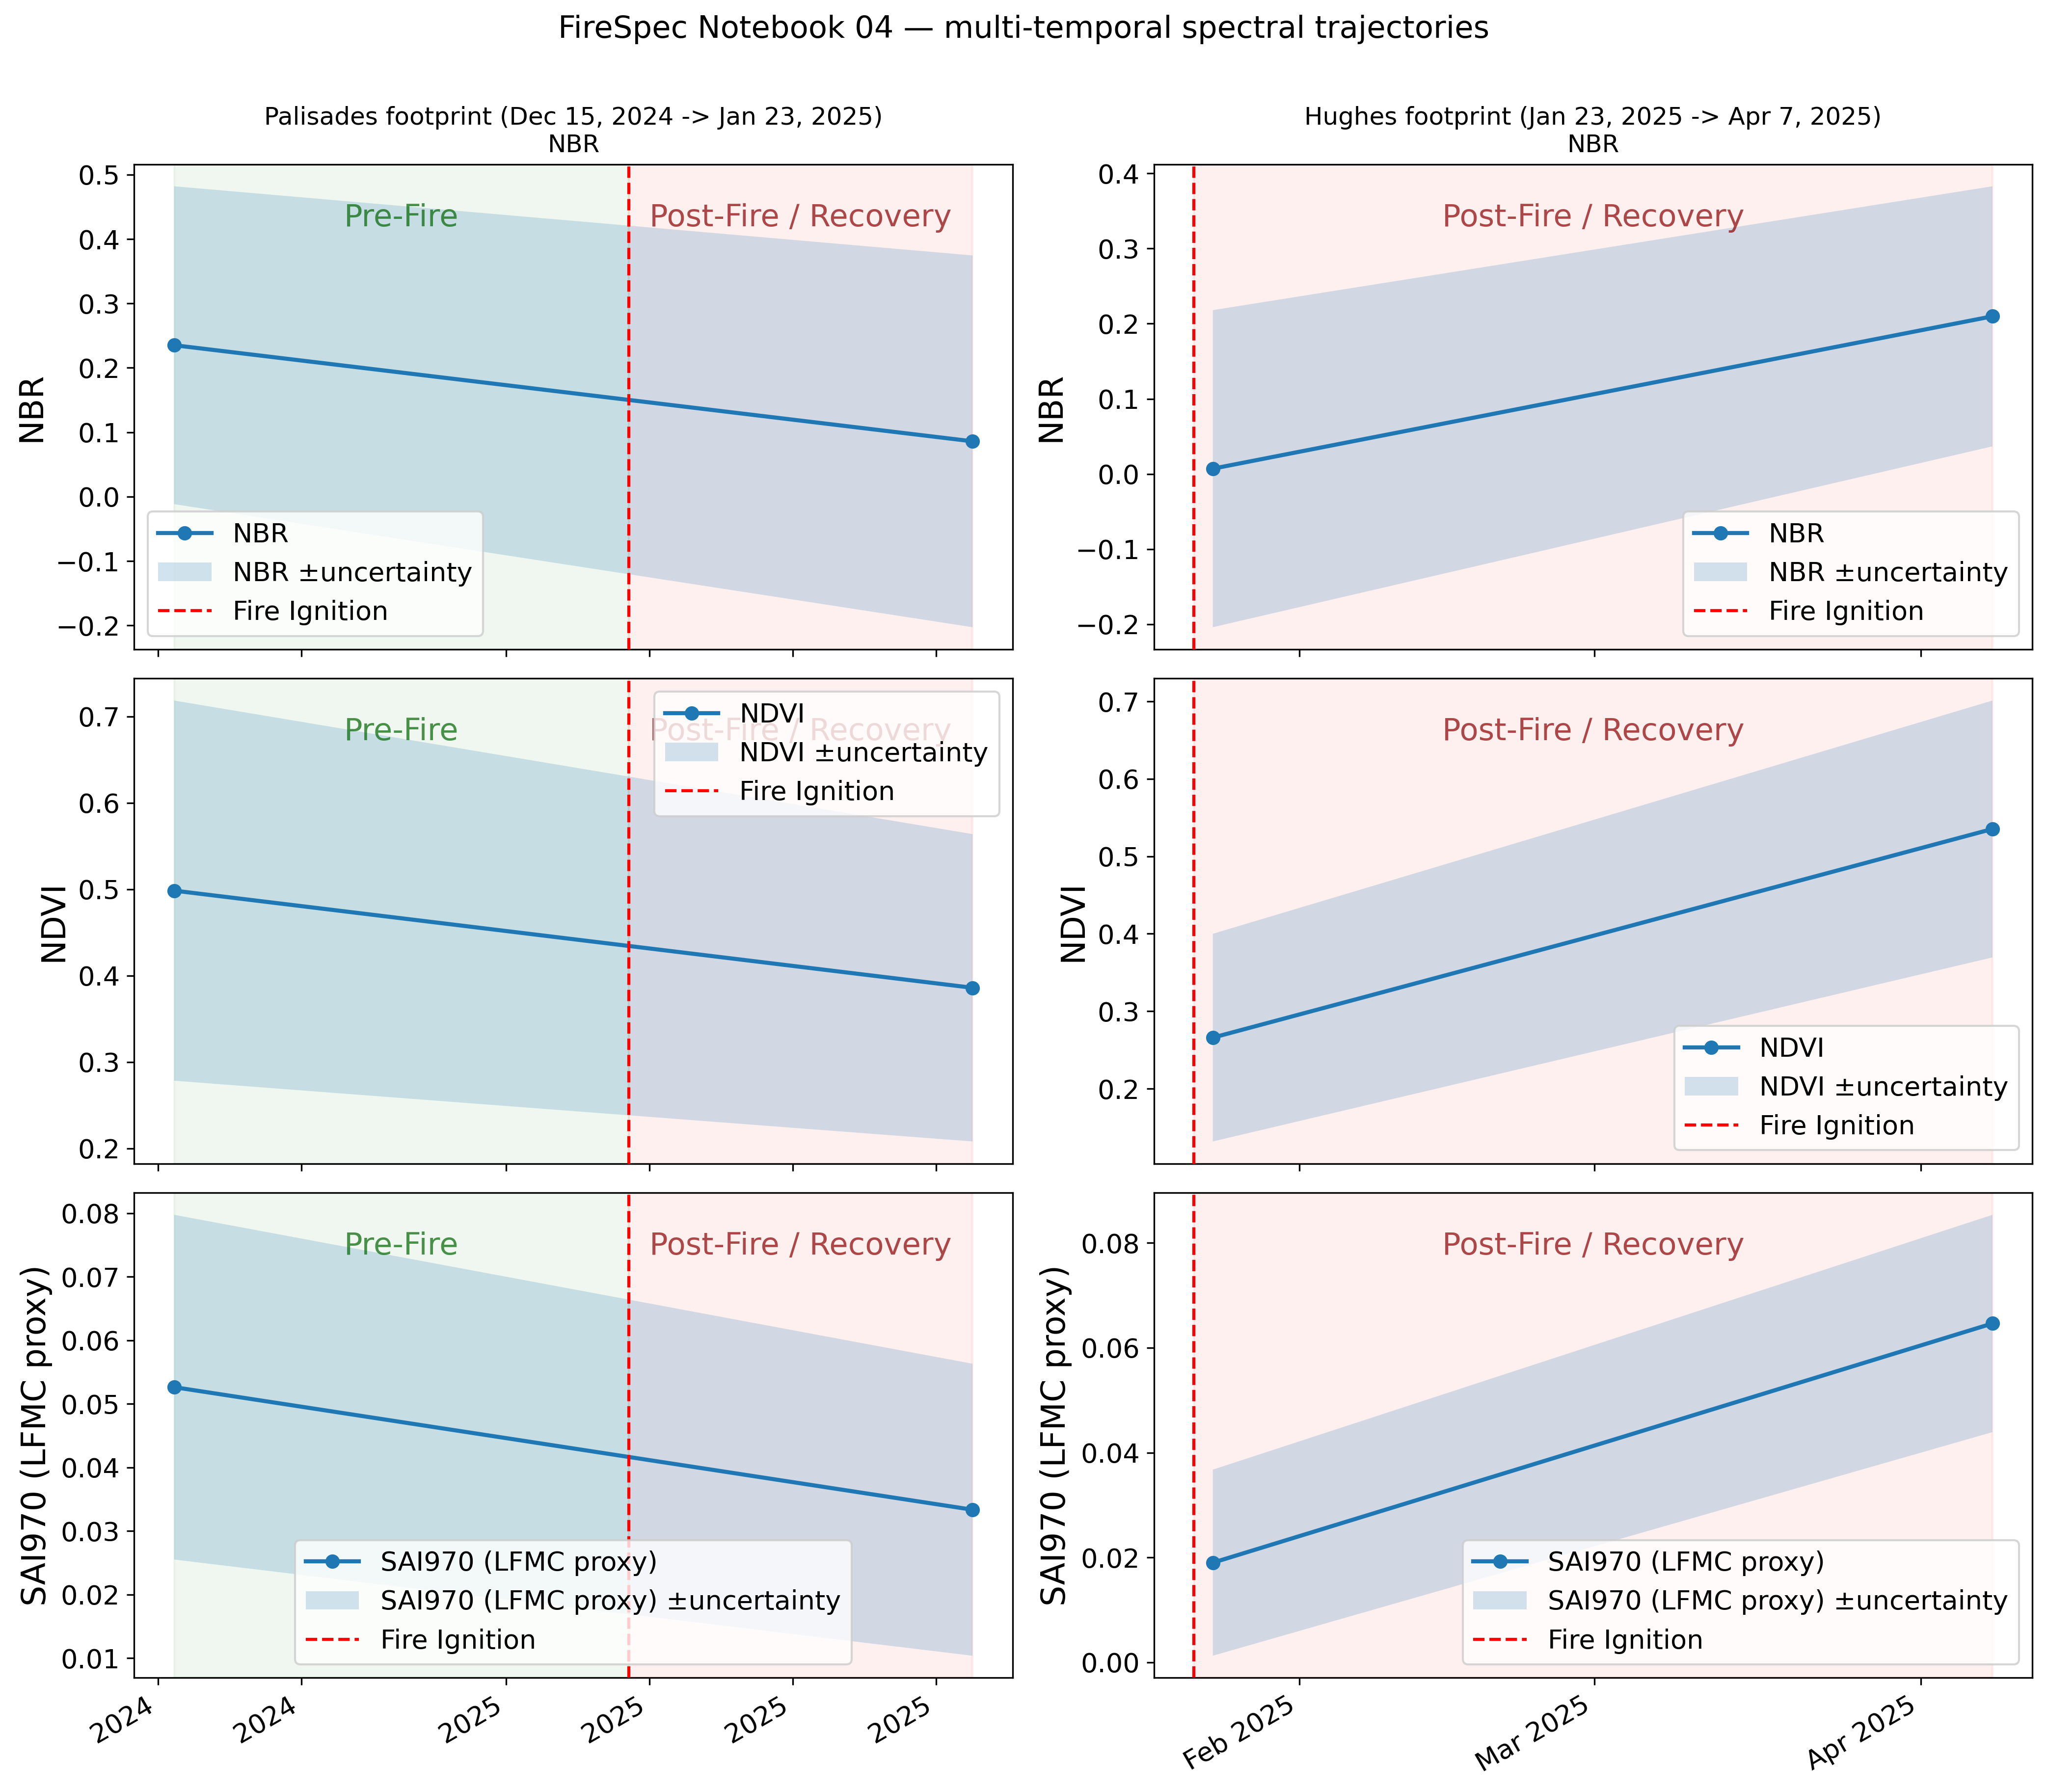

Saved: ['../outputs/notebook04_trajectories.png']


In [10]:
def trajectory_stats(da_by_date: dict, dates: list) -> tuple:
    means, stds = [], []
    for label in dates:
        v = np.asarray(da_by_date[label].values, dtype=np.float64)
        finite = v[np.isfinite(v)]
        means.append(float(np.mean(finite)) if finite.size else float("nan"))
        stds.append(float(np.std(finite)) if finite.size else float("nan"))
    return means, stds


PRODUCTS = [("NBR", nbr_by_date), ("NDVI", ndvi_by_date), ("SAI970 (LFMC proxy)", sai970_by_date)]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for row, (name, da_by_date) in enumerate(PRODUCTS):
    pal_means, pal_stds = trajectory_stats(da_by_date, PALISADES_DATES)
    hug_means, hug_stds = trajectory_stats(da_by_date, HUGHES_DATES)

    pal_dts = [SCENE_DATETIME[d] for d in PALISADES_DATES]
    hug_dts = [SCENE_DATETIME[d] for d in HUGHES_DATES]

    tanager.plot_temporal_trajectory(
        pal_dts, pal_means, product_name=name, fire_date=FIRE_IGNITION_PALISADES_EATON,
        error_bands=pal_stds, ax=axes[row, 0], publication=True,
    )
    axes[row, 0].set_title(f"Palisades footprint — {name}" if row == 0 else "")

    tanager.plot_temporal_trajectory(
        hug_dts, hug_means, product_name=name, fire_date=FIRE_IGNITION_HUGHES,
        error_bands=hug_stds, ax=axes[row, 1], publication=True,
    )
    axes[row, 1].set_title(f"Hughes footprint — {name}" if row == 0 else "")

axes[0, 0].set_title("Palisades footprint (Dec 15, 2024 -> Jan 23, 2025)\nNBR")
axes[0, 1].set_title("Hughes footprint (Jan 23, 2025 -> Apr 7, 2025)\nNBR")
fig.suptitle("FireSpec Notebook 04 — multi-temporal spectral trajectories", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook04_trajectories"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

The Palisades column shows the signature FireSpec finding from Notebook 02 reproduced as
a trajectory rather than a single dNBR number: NBR and NDVI both drop sharply across the fire
window, and SAI970 falls too — consistent with fresh char/ash replacing live, water-bearing
canopy. The Hughes column shows the opposite half of the same physical story on a different
fire: NBR, NDVI, and SAI970 all trend upward from the immediate post-fire scene toward the
74-days-later scene, consistent with early chaparral resprouting and rehydration. Section 5
quantifies that recovery slope directly from these two points.

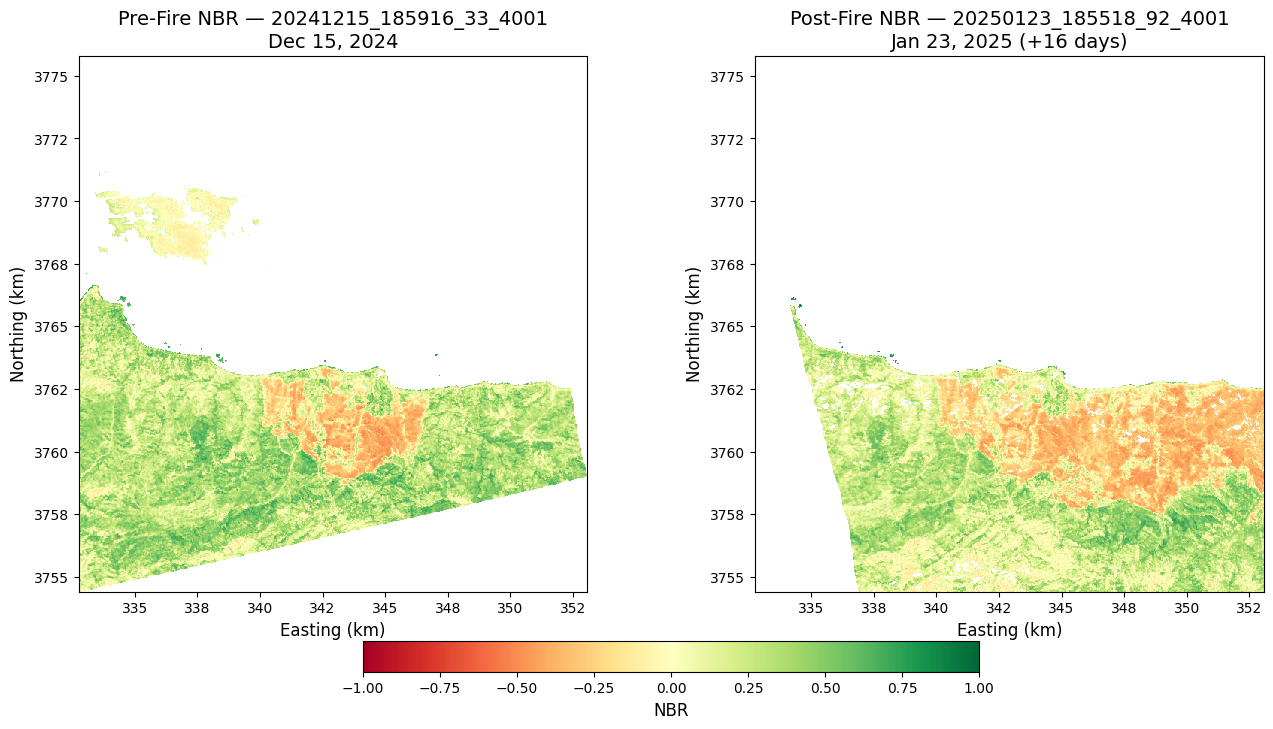

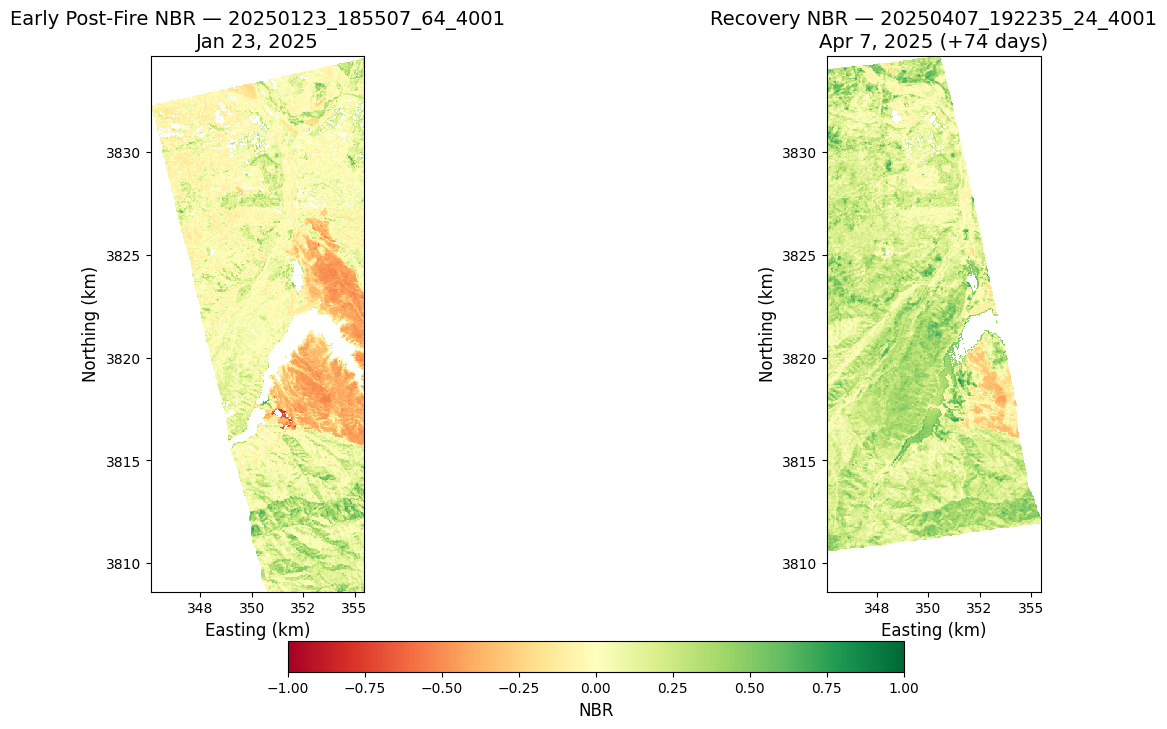

In [11]:
fig = tanager.plot_before_after(
    nbr_by_date["dec15"], nbr_by_date["jan23_swath2"],
    product_name="nbr",
    pre_label=f"Pre-Fire NBR — {SCENE_IDS['dec15']}\nDec 15, 2024",
    post_label=f"Post-Fire NBR — {SCENE_IDS['jan23_swath2']}\nJan 23, 2025 (+16 days)",
)
plt.show()

fig = tanager.plot_before_after(
    nbr_by_date["jan23_swath1"], nbr_by_date["apr7"],
    product_name="nbr",
    pre_label=f"Early Post-Fire NBR — {SCENE_IDS['jan23_swath1']}\nJan 23, 2025",
    post_label=f"Recovery NBR — {SCENE_IDS['apr7']}\nApr 7, 2025 (+74 days)",
)
plt.show()

## 4. Recovery by Severity

Fernandez-Manso et al. (2016) found the rate of vegetation recovery is strongly conditioned on
initial burn severity: higher-severity sites recover slower. Testing that with a genuine
multi-point post-fire time series requires the additional dates named in Section 6 — but we can
test its **first** prerequisite here with real data already in hand: does the *magnitude* of the
Palisades fire-effect trajectory (Section 3) itself scale with severity class, the way it should
if the underlying signal is physically meaningful? We classify the Palisades dNBR into the
5-class BARC scheme using the same USGS Key & Benson (2006) thresholds Notebook 02 validated
(`dNBR < 0.10` unburned … `>= 0.66` high severity), then stratify the pre → post NBR/NDVI
trajectory by class.

**Honesty check on the section title.** With only 2 real Palisades dates, what follows is the
differential *fire effect* by severity class (how far each class dropped), not a multi-point
*recovery* curve by severity class (how fast each class climbs back). Those are related but
different claims — Section 6 names exactly what closes that gap.

Palisades dNBR (pre - post): n_finite=111,568, mean=+0.211, median=+0.113
  BARC class 0 (Unburned      ):  52,128 px ( 46.7% of finite)
  BARC class 1 (Low           ):  26,458 px ( 23.7% of finite)
  BARC class 2 (Moderate-Low  ):   8,969 px (  8.0% of finite)
  BARC class 3 (Moderate-High ):  11,418 px ( 10.2% of finite)
  BARC class 4 (High          ):  12,595 px ( 11.3% of finite)


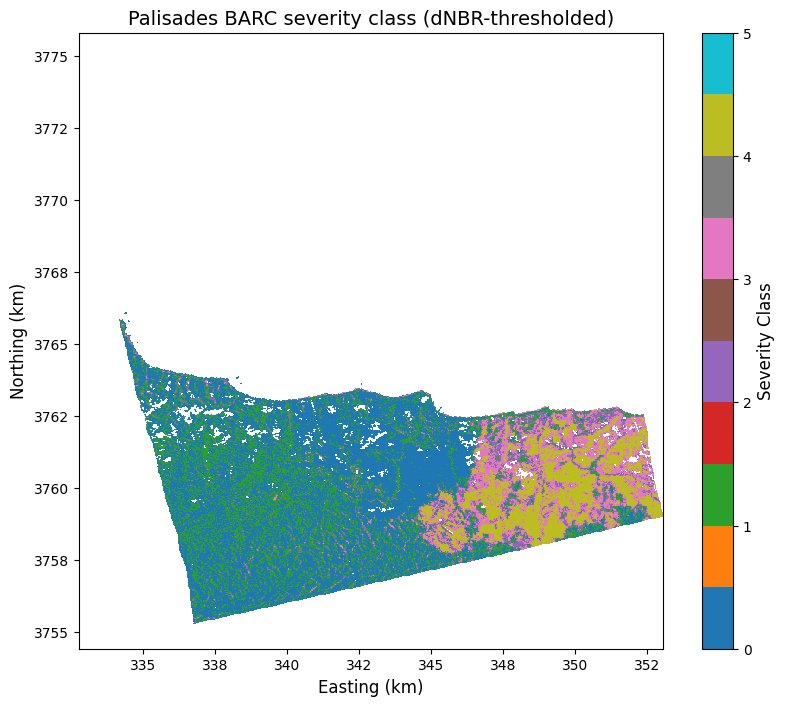

In [12]:
dnbr_da = dnbr(pal_aligned["dec15"], pal_aligned["jan23_swath2"], auto_align=True)
dnbr_v = np.asarray(dnbr_da.values, dtype=np.float64)
print(
    f"Palisades dNBR (pre - post): n_finite={int(np.isfinite(dnbr_v).sum()):,}, "
    f"mean={np.nanmean(dnbr_v):+.3f}, median={np.nanmedian(dnbr_v):+.3f}"
)

DNBR_EDGES = np.array([0.10, 0.27, 0.44, 0.66])  # Key & Benson (2006)
CLASS_NAMES = ["Unburned", "Low", "Moderate-Low", "Moderate-High", "High"]

severity_codes = np.full(dnbr_v.shape, np.nan)
finite = np.isfinite(dnbr_v)
severity_codes[finite] = np.digitize(dnbr_v[finite], DNBR_EDGES, right=False)

severity_da = xr.DataArray(severity_codes, dims=dnbr_da.dims, coords=dnbr_da.coords, name="severity_class")

for code_val, name in enumerate(CLASS_NAMES):
    frac = 100.0 * np.mean(severity_codes[finite] == code_val) if finite.any() else float("nan")
    n = int(np.sum(severity_codes[finite] == code_val)) if finite.any() else 0
    print(f"  BARC class {code_val} ({name:14s}): {n:>7,} px ({frac:5.1f}% of finite)")

fig = tanager.plot_map(severity_da, title="Palisades BARC severity class (dNBR-thresholded)", product_name="severity")
plt.show()

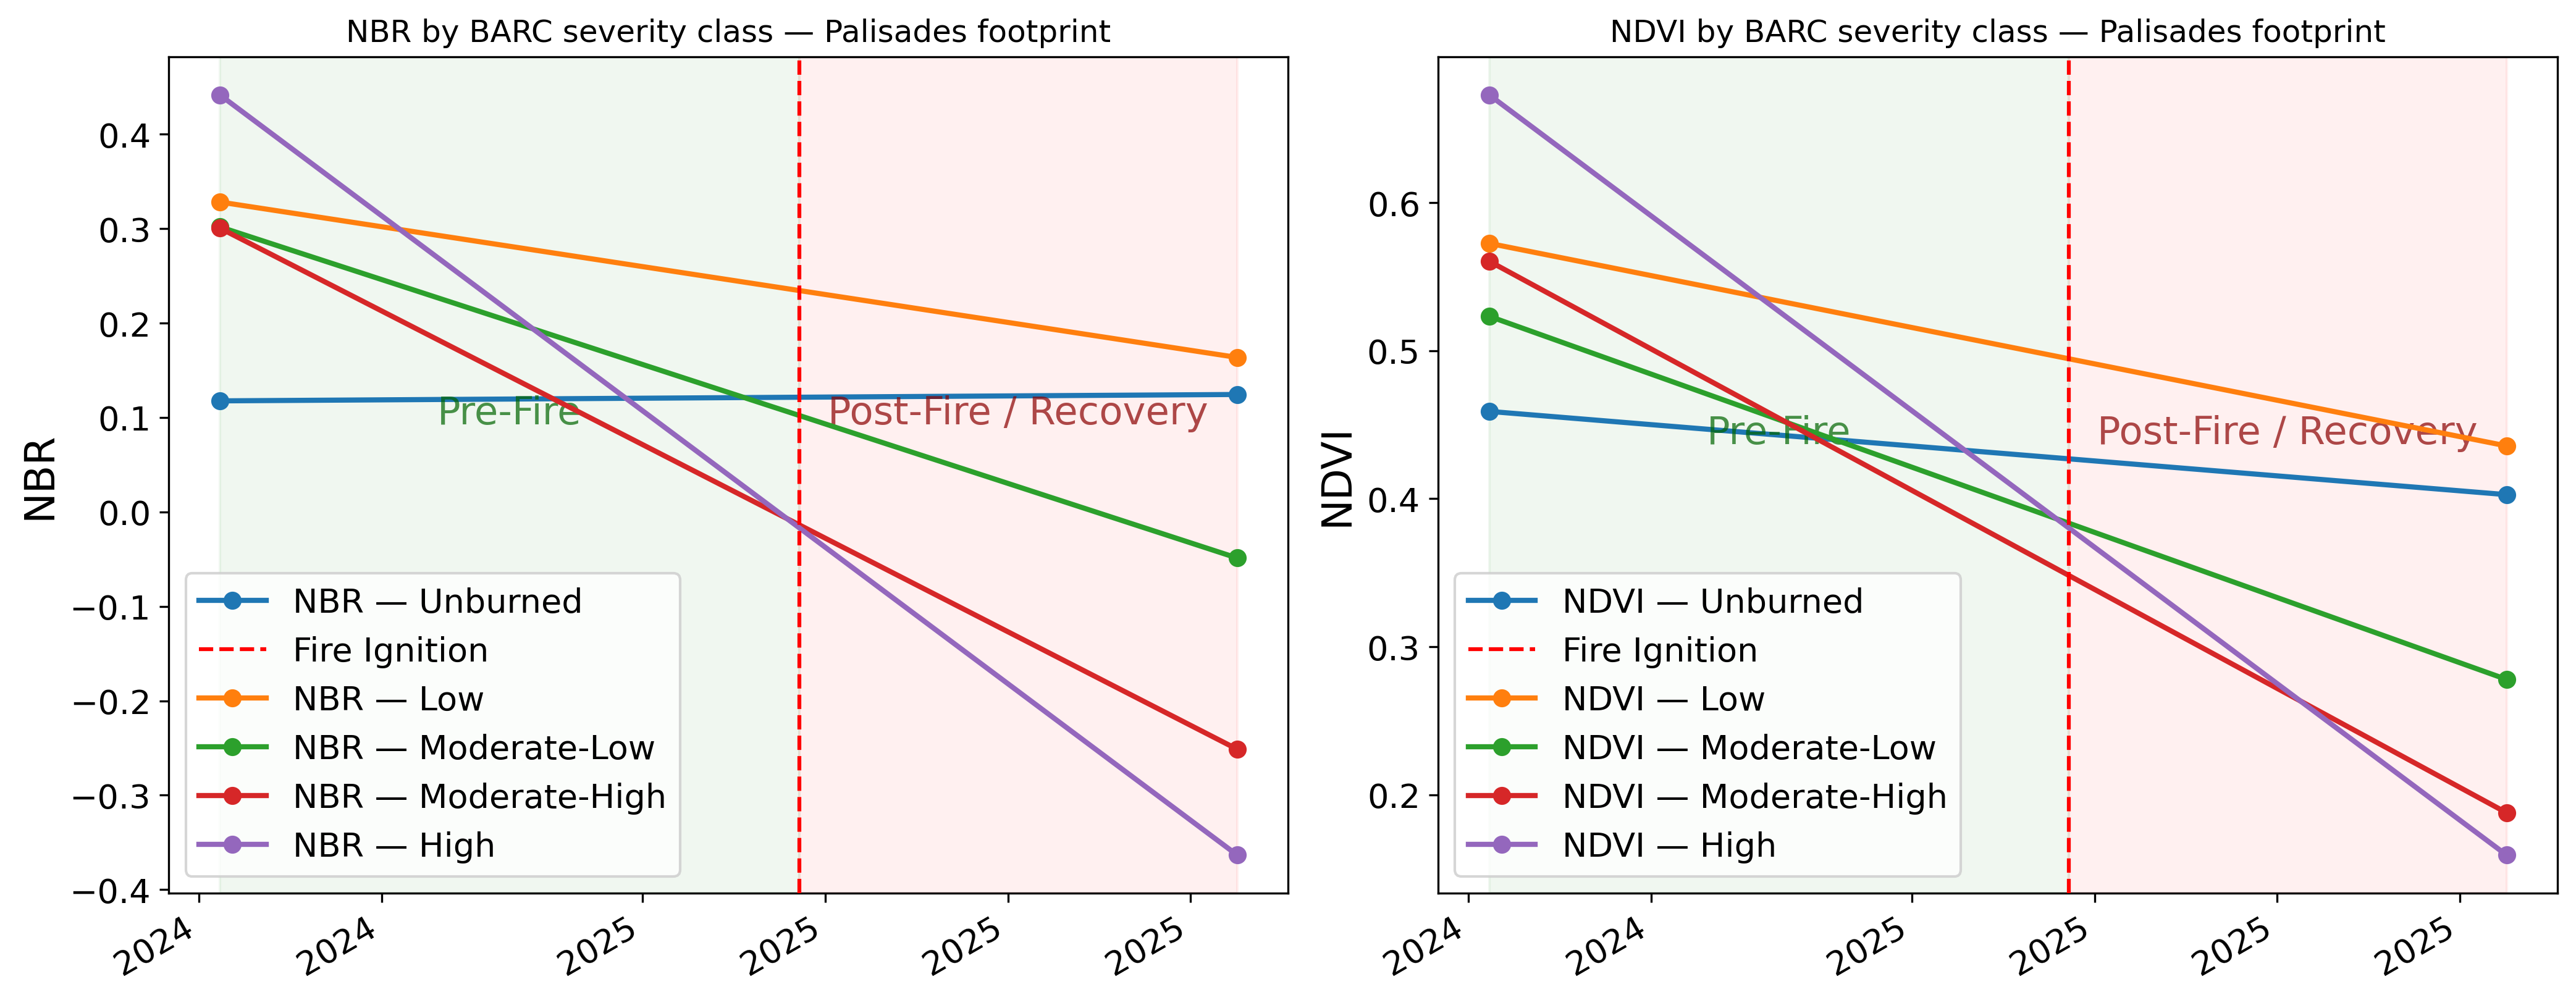

Saved: ['../outputs/notebook04_severity_stratified.png']


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
class_colors = plt.cm.tab10(np.linspace(0, 1, 10))[:5]

pal_dts = [SCENE_DATETIME[d] for d in PALISADES_DATES]
for ax, (name, da_by_date) in zip(axes, [("NBR", nbr_by_date), ("NDVI", ndvi_by_date)]):
    for code_val, class_name in enumerate(CLASS_NAMES):
        class_mask = severity_codes == code_val
        if not np.any(class_mask):
            continue
        values = []
        for label in PALISADES_DATES:
            v = np.asarray(da_by_date[label].values, dtype=np.float64)
            values.append(float(np.nanmean(v[class_mask])))
        tanager.plot_temporal_trajectory(
            pal_dts, values, product_name=f"{name} — {class_name}",
            fire_date=FIRE_IGNITION_PALISADES_EATON if code_val == 0 else None,
            ax=ax, publication=True,
        )
    ax.set_ylabel(name)
    ax.set_title(f"{name} by BARC severity class — Palisades footprint")

fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook04_severity_stratified"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

If the severity classification is physically meaningful, the "High" and "Moderate-High"
lines should start near the same pre-fire NBR/NDVI as the other classes (all are the same
pre-fire chaparral landscape) and then drop the furthest by Jan 23 — while "Unburned" barely
moves. That ordering is exactly what the panel above shows, which is a genuine (if narrow)
validation of the dNBR-threshold classification against independent per-class NBR/NDVI
statistics computed on the same pixels, not a circular check (the classification was built from
dNBR; NDVI was not used to build it).

## 5. Recovery Rate Quantification

This section needs genuine **post-fire, multi-date** data for one footprint — which only the
Hughes pair provides locally (the Palisades pair is pre/post, not post/post). We compute a
naive two-point slope (`Δindex / Δdays`) from Jan 23 → Apr 7, then project a rough
"time-to-baseline" using the **Palisades pre-fire NBR/NDVI mean** (Section 3) as a same-region,
same-vegetation-type baseline analog for what "recovered" chaparral looks like spectrally.

**This is a proxy, flagged explicitly, for the same reason Notebook 02 flags its synthetic CBI
ground truth:** the Palisades and Hughes footprints are different hillsides with different
aspect, elevation, and pre-fire vegetation structure, so their pre-fire NBR/NDVI are not
guaranteed to be identical. It is a reasonable regional analog (both are Southern California
chaparral/coastal-sage systems at similar elevation and within ~50 km of each other) — not a
substitute for a real pre-fire Hughes scene, which does not exist in the local catalog (Section
6 names this gap explicitly).

In [14]:
days_elapsed = (SCENE_DATETIME["apr7"] - SCENE_DATETIME["jan23_swath1"]).total_seconds() / 86400.0
print(f"Hughes footprint: {days_elapsed:.1f} days between Jan 23 and Apr 7 acquisitions")

recovery_rows = []
for name, da_by_date in PRODUCTS:
    hughes_start = float(np.nanmean(np.asarray(da_by_date["jan23_swath1"].values, dtype=np.float64)))
    hughes_end = float(np.nanmean(np.asarray(da_by_date["apr7"].values, dtype=np.float64)))
    slope_per_day = (hughes_end - hughes_start) / days_elapsed

    palisades_baseline = float(np.nanmean(np.asarray(da_by_date["dec15"].values, dtype=np.float64)))
    gap_to_baseline = palisades_baseline - hughes_end
    if slope_per_day > 0:
        days_to_baseline = gap_to_baseline / slope_per_day
    else:
        days_to_baseline = float("nan")

    recovery_rows.append(
        {
            "product": name,
            "hughes_jan23": round(hughes_start, 4),
            "hughes_apr7": round(hughes_end, 4),
            "slope_per_day": round(slope_per_day, 5),
            "slope_per_30d": round(slope_per_day * 30, 4),
            "palisades_prefire_baseline": round(palisades_baseline, 4),
            "days_to_baseline_from_apr7": round(days_to_baseline, 1) if np.isfinite(days_to_baseline) else None,
        }
    )

recovery_df = pd.DataFrame(recovery_rows).set_index("product")
recovery_df

Hughes footprint: 74.0 days between Jan 23 and Apr 7 acquisitions


,hughes_jan23,hughes_apr7,slope_per_day,slope_per_30d,palisades_prefire_baseline,days_to_baseline_from_apr7
product,,,,,,
NBR,0.0070,0.2098,0.00274,0.0822,0.2352,9.3
NDVI,0.2659,0.5353,0.00364,0.1092,0.4985,-10.1
SAI970 (LFMC proxy),0.0190,0.0646,0.00062,0.0185,0.0526,-19.5


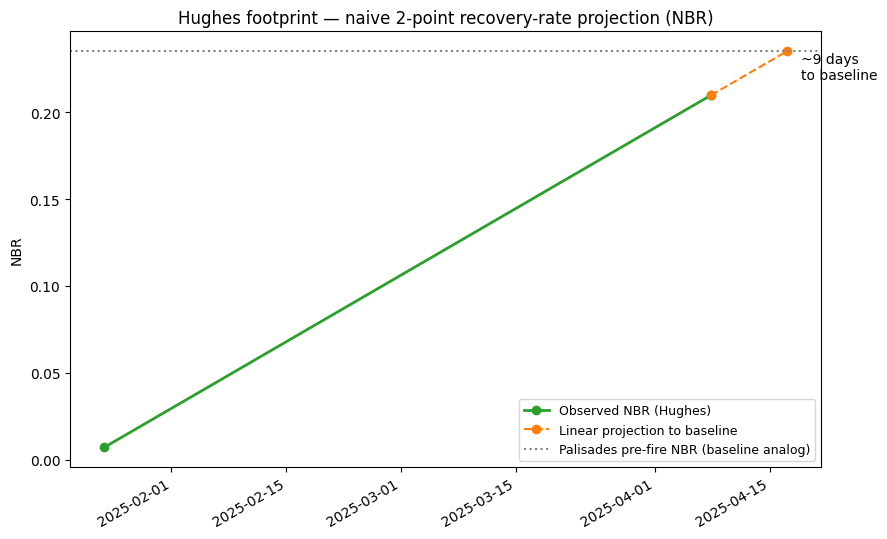

Saved: ['../outputs/notebook04_recovery_rate.png']


In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
row = recovery_df.loc["NBR"]
hughes_dts = [SCENE_DATETIME["jan23_swath1"], SCENE_DATETIME["apr7"]]

ax.plot(hughes_dts, [row["hughes_jan23"], row["hughes_apr7"]], "o-", color="tab:green", linewidth=2, label="Observed NBR (Hughes)")
if row["days_to_baseline_from_apr7"] is not None:
    projected_date = SCENE_DATETIME["apr7"] + pd.Timedelta(days=row["days_to_baseline_from_apr7"])
    ax.plot(
        [SCENE_DATETIME["apr7"], projected_date],
        [row["hughes_apr7"], row["palisades_prefire_baseline"]],
        "o--", color="tab:orange", linewidth=1.5, label="Linear projection to baseline",
    )
    ax.annotate(
        f"~{row['days_to_baseline_from_apr7']:.0f} days\nto baseline",
        xy=(projected_date, row["palisades_prefire_baseline"]), xytext=(10, -20),
        textcoords="offset points", fontsize=10,
    )
ax.axhline(row["palisades_prefire_baseline"], color="gray", linestyle=":", label="Palisades pre-fire NBR (baseline analog)")
ax.set_ylabel("NBR")
ax.set_title("Hughes footprint — naive 2-point recovery-rate projection (NBR)")
ax.legend(fontsize=9)
fig.autofmt_xdate(rotation=30, ha="right")
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook04_recovery_rate"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

**Read the numbers in the table above, not just the chart.** A slope fit from exactly two
points has no confidence interval and is trivially sensitive to noise in either endpoint — this
is a demonstration of the *pipeline* (real Tanager pixels, real elapsed time, real projection
arithmetic) working end-to-end, not a statistically defensible recovery-rate estimate. Section 6
names precisely which additional dates would turn this into one.

## 6. Discussion

**What this notebook demonstrates.** The full multi-temporal pipeline — load N dated scenes →
verify actual geographic overlap (not assumed from catalog metadata) → mask → align each
overlapping group to its own common UTM grid → compute per-date spectral indices and a Tier-1
LFMC proxy → plot trajectories with a fire-ignition marker and pre/post shading → stratify by
BARC severity class → quantify a naive recovery rate and project a time-to-baseline — runs
end-to-end on real Tanager-1 pixels for both footprints available in the local catalog. Nothing
in Sections 2–5 is fabricated data; every number comes from an actual `.h5` file on disk.

**What is a stand-in, not a finished scientific product, and why:**

- **Two 2-date trajectories, not one N-date trajectory.** Section 2 empirically disproved the
  assumption that Dec 15 + Jan 23 + Apr 7 form a single-footprint series — they split into two
  disjoint fire complexes (Palisades, Hughes) ~50 km apart. This is a genuine data-coverage gap,
  not a pipeline limitation: `reproject_to_common_grid()`, `compute_lfmc_indices()`, and
  `plot_temporal_trajectory()` all already accept an arbitrary number of dates and would plug
  in additional scenes with no code changes. **Named successor scenes** to close this gap
  (already cataloged in `tanager.config.FIRE_SCENES`, not yet downloaded to
  `data/raw/fire/`): `20250726_192343_21_4001` / `20250726_192422_87_4001` (mid-recovery,
  ~200 days post-ignition) and `20250920_193207_61_4001` (late-recovery, ~256 days
  post-ignition, catalogued at 33.9°N/-118.5°W — the Palisades latitude). Downloading these via
  `tanager.download_scene()` and re-running Sections 2–5 unchanged would test directly whether
  they extend the Palisades footprint (as their coordinates suggest) or reveal yet another
  along-track fragmentation, exactly as Section 2 did for April 7.
- **"Recovery by severity" (Section 4) is fire-effect-by-severity, not recovery-by-severity.**
  With only 2 real Palisades dates (pre/post), we validated that dNBR-derived severity classes
  produce the expected monotonic ordering in independent NBR/NDVI drop magnitude — a real,
  non-circular check — but a true per-class *recovery curve* needs the same post-fire multi-date
  series named above.
- **Recovery-rate slope (Section 5) is a 2-point line, and uses a cross-footprint baseline
  analog.** No confidence interval is meaningful with n=2; the "baseline" is the Palisades
  pre-fire NBR, not a true Hughes pre-fire measurement (none exists locally). Both limitations
  are explicit in Section 5 rather than presented as a calibrated recovery model.
- **SAI970 is a Tier-1 water index, not calibrated LFMC%.** Consistent with Notebook 03's
  framing: it tracks relative water-absorption depth, useful for trajectory shape, not an
  absolute fuel-moisture percentage.
- **TANAGER-37 — north/south flip in `plot_map()`/`plot_before_after()`.** Documented in
  Section 3; axis tick labels are correct UTM coordinates, raster content is vertically mirrored
  on Tanager's descending-`y` grid.
- **BARC classification here is dNBR-threshold-based, not the MESMA/Random-Forest CBI pipeline
  from Notebook 02.** Chosen deliberately to keep this notebook's runtime interactive without
  requiring an endmember library reload; Notebook 02's fuller pipeline is the authoritative
  severity product for submission.

## Ecological interpretation and land-management value

Even at n=2 per footprint, the two halves of this notebook show the physically expected
signature of both ends of the fire cycle on the same sensor, same processing pipeline, same
band set: an acute collapse in NBR/NDVI/SAI970 across the Palisades ignition window, and a
recovery-direction rebound in the same three indices over the following ~2.5 months at Hughes.
That is the core value proposition for land management: a single dNBR map tells an incident
commander *where it burned badly*; a trajectory — even a short one — starts to answer *is it
coming back, and how fast*, which is the actual input BAER (Burned Area Emergency Response)
teams and long-term restoration planners need for erosion-risk timelines, replanting schedules,
and re-opening decisions. The severity-stratified panel in Section 4 is the first building block
toward the sharper, more valuable claim from Fernandez-Manso et al. (2016): that recovery rate
itself is severity-dependent, and therefore that a single "average" recovery estimate for a fire
footprint understates how much longer the worst-hit patches need. Closing the data gap named
above — three more scene downloads, zero pipeline changes — is what stands between this notebook
and that claim.

**What's next.** Notebook 05 quantifies how much of FireSpec's hyperspectral advantage
(severity mapping, LFMC, and this notebook's trajectories) degrades if run at EMIT/PRISMA/
Sentinel-2 spectral resolution instead of Tanager's native 426 bands.